# Baseline Models and their Evaluations

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
pd.set_option("mode.copy_on_write", True)

In [3]:
df_players_stats = pd.read_csv("../data/modified/player_stats.csv")
df_players_stats.shape

/tmp/ipykernel_8081/3770416815.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_players_stats = pd.read_csv("../data/modified/player_stats.csv")


(1570242, 40)

In [4]:
#display all columns on screen
pd.set_option('display.max_columns', 40)

In [5]:
df_players_stats.head(5)

,firstName,lastName,personId,gameId,gameDateTimeEst,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType,gameLabel,gameSubLabel,seriesGameNumber,win,home,numMinutes,points,assists,blocks,steals,fieldGoalsAttempted,fieldGoalsMade,fieldGoalsPercentage,threePointersAttempted,threePointersMade,threePointersPercentage,freeThrowsAttempted,freeThrowsMade,freeThrowsPercentage,reboundsDefensive,reboundsOffensive,reboundsTotal,foulsPersonal,turnovers,plusMinusPoints,numMinutes_missing,rolling_minutes,player_median_minutes,fantasy_points,is_playoff
0,Byron,Scott,2,28300002,1983-10-28 20:00:00,Los Angeles,Lakers,Kansas City,Kings,Regular Season,NaN,NaN,NaN,1,0,4.0,2.0,0.0,0.0,2.0,2.0,1.0,0.500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,29.0,6.0,0
1,Byron,Scott,2,28300010,1983-10-29 20:00:00,Los Angeles,Lakers,Utah,Jazz,Regular Season,NaN,NaN,NaN,1,0,8.0,0.0,0.0,0.0,0.0,1.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,3.0,0.0,0.0,0,4.000000,29.0,1.2,0
2,Byron,Scott,2,28300035,1983-11-02 20:00:00,Los Angeles,Lakers,San Diego,Clippers,Regular Season,NaN,NaN,NaN,0,0,22.0,8.0,6.0,1.0,2.0,10.0,4.0,0.400,1.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,1.0,1.0,0.0,0,6.000000,29.0,27.3,0
3,Byron,Scott,2,28300053,1983-11-05 20:00:00,Los Angeles,Lakers,Dallas,Mavericks,Regular Season,NaN,NaN,NaN,0,0,21.0,7.0,1.0,1.0,1.0,14.0,3.0,0.213,1.0,0.0,0.0,2.0,1.0,0.5,2.0,1.0,3.0,0.0,0.0,0.0,0,11.333333,29.0,16.1,0
4,Byron,Scott,2,28300066,1983-11-08 20:00:00,Los Angeles,Lakers,Denver,Nuggets,Regular Season,NaN,NaN,NaN,1,0,17.0,12.0,0.0,1.0,0.0,8.0,3.0,0.375,1.0,1.0,1.0,5.0,5.0,1.0,2.0,2.0,4.0,3.0,7.0,0.0,0,13.750000,29.0,15.3,0


A rolling average (also called a moving average) is a statistic that takes the average of the last N data points in a time-ordered sequence.
A rolling average answers the question:
“How has this player been performing in their most recent games?”

| Game | FP | last_3 average (using previous games) |
| ---- | -- | ------------------------------------- |
| G1   | 10 | — (no previous games)                 |
| G2   | 20 | 10                                    |
| G3   | 30 | (10 + 20) / 2                         |
| G4   | 40 | (10 + 20 + 30) / 3                    |
| G5   | 50 | (20 + 30 + 40) / 3                    |


In [6]:
# Helper function to create rolling feature
def add_rolling_feature(df, col, windows=[3, 5]):
    for w in windows:
        new_col = f'{col}_last_{w}'
        # shift(1) allows to use only previous games 
        df[new_col] = (
            df.groupby('personId')[col].transform(lambda x: x.shift(1).rolling(window=w, min_periods=1).mean())
                       )
    return df

In [7]:
base_features = [
  "points",
  "assists",
  "reboundsTotal",
  "steals",
  "blocks",
  "turnovers",
  "foulsPersonal"
]

for base_col in base_features:
    df_players_stats = add_rolling_feature(df_players_stats, base_col, windows=[3, 5])

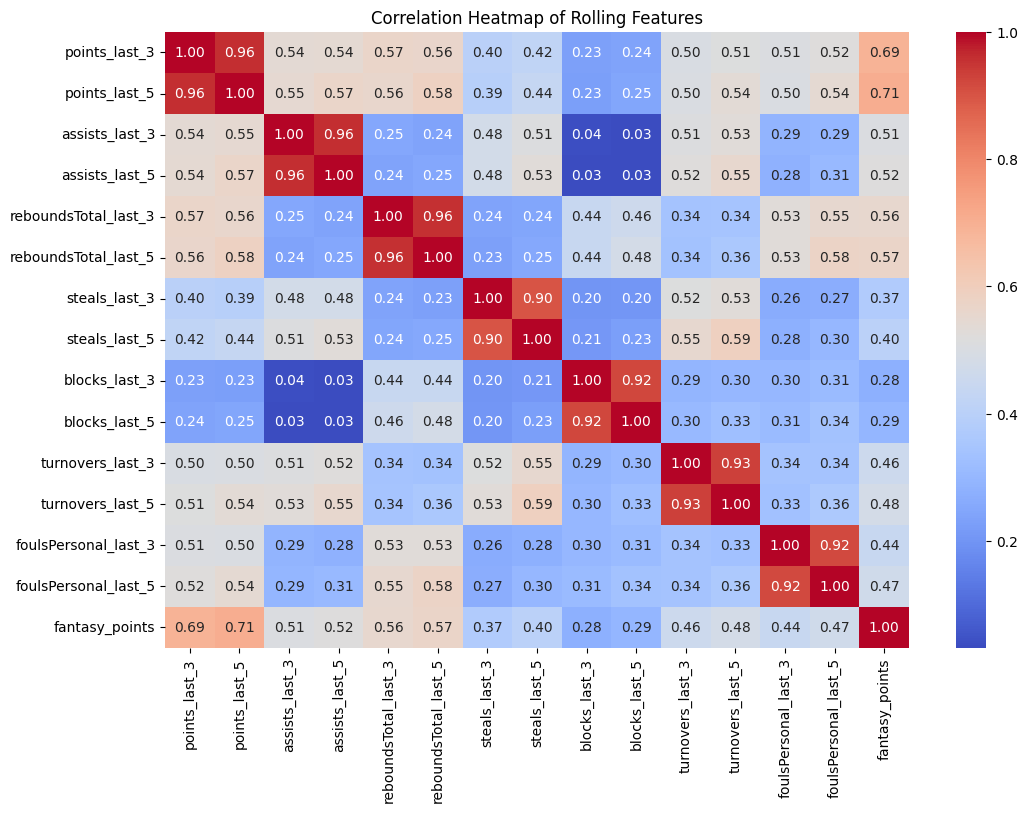

In [8]:
#Correlation heatmap of the rolling features vs fantasy_points
plt.figure(figsize=(12, 8))
corr_cols = [c for c in df_players_stats.columns if 'last_' in c] + ['fantasy_points']
sns.heatmap(df_players_stats[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap of Rolling Features")
plt.show()

In [9]:
corr_cols

['points_last_3',
 'points_last_5',
 'assists_last_3',
 'assists_last_5',
 'reboundsTotal_last_3',
 'reboundsTotal_last_5',
 'steals_last_3',
 'steals_last_5',
 'blocks_last_3',
 'blocks_last_5',
 'turnovers_last_3',
 'turnovers_last_5',
 'foulsPersonal_last_3',
 'foulsPersonal_last_5',
 'fantasy_points']

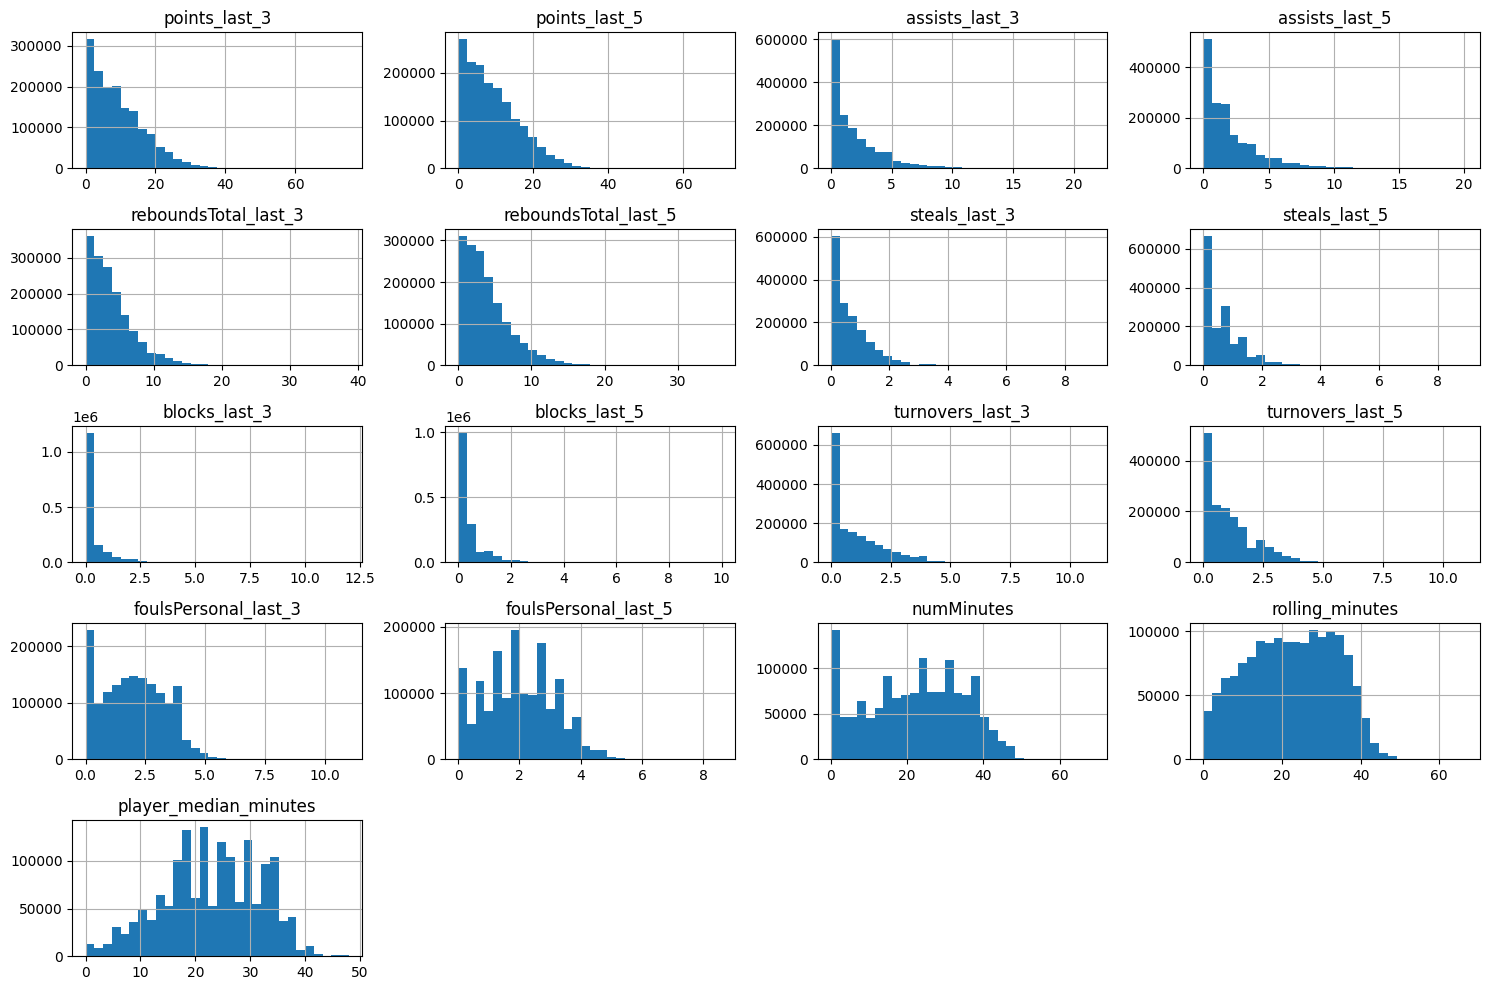

In [10]:
plot_cols = [
    'points_last_3',
    'points_last_5',
    'assists_last_3',
    'assists_last_5',
    'reboundsTotal_last_3',
    'reboundsTotal_last_5',
    'steals_last_3',
    'steals_last_5',
    'blocks_last_3',
    'blocks_last_5',
    'turnovers_last_3',
    'turnovers_last_5',
    'foulsPersonal_last_3',
    'foulsPersonal_last_5',
    'numMinutes',
    'rolling_minutes',
    'player_median_minutes'
]

df = df_players_stats[plot_cols]

df.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

### Linear Regression & Random Forest

In [11]:
#choose features and drop first few games because rolling features will be NaN for x < w 
features_cols = [
    'points_last_3',
    'points_last_5',
    'assists_last_3',
    'assists_last_5',
    'reboundsTotal_last_3',
    'reboundsTotal_last_5',
    'steals_last_3',
    'steals_last_5',
    'blocks_last_3',
    'blocks_last_5',
    'turnovers_last_3',
    'turnovers_last_5',
    'foulsPersonal_last_3',
    'foulsPersonal_last_5'
]

df_rolling_features = df_players_stats.copy()
df_rolling_features[features_cols] = df_rolling_features[features_cols].fillna(0)
df_rolling_features.head()

,firstName,lastName,personId,gameId,gameDateTimeEst,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType,gameLabel,gameSubLabel,seriesGameNumber,win,home,numMinutes,points,assists,blocks,steals,...,plusMinusPoints,numMinutes_missing,rolling_minutes,player_median_minutes,fantasy_points,is_playoff,points_last_3,points_last_5,assists_last_3,assists_last_5,reboundsTotal_last_3,reboundsTotal_last_5,steals_last_3,steals_last_5,blocks_last_3,blocks_last_5,turnovers_last_3,turnovers_last_5,foulsPersonal_last_3,foulsPersonal_last_5
0,Byron,Scott,2,28300002,1983-10-28 20:00:00,Los Angeles,Lakers,Kansas City,Kings,Regular Season,NaN,NaN,NaN,1,0,4.0,2.0,0.0,0.0,2.0,...,0.0,0,NaN,29.0,6.0,0,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Byron,Scott,2,28300010,1983-10-29 20:00:00,Los Angeles,Lakers,Utah,Jazz,Regular Season,NaN,NaN,NaN,1,0,8.0,0.0,0.0,0.0,0.0,...,0.0,0,4.000000,29.0,1.2,0,2.000000,2.000000,0.000000,0.00,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,Byron,Scott,2,28300035,1983-11-02 20:00:00,Los Angeles,Lakers,San Diego,Clippers,Regular Season,NaN,NaN,NaN,0,0,22.0,8.0,6.0,1.0,2.0,...,0.0,0,6.000000,29.0,27.3,0,1.000000,1.000000,0.000000,0.00,0.500000,0.500000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.500000,1.500000
3,Byron,Scott,2,28300053,1983-11-05 20:00:00,Los Angeles,Lakers,Dallas,Mavericks,Regular Season,NaN,NaN,NaN,0,0,21.0,7.0,1.0,1.0,1.0,...,0.0,0,11.333333,29.0,16.1,0,3.333333,3.333333,2.000000,2.00,1.666667,1.666667,1.333333,1.333333,0.333333,0.333333,0.333333,0.333333,1.333333,1.333333
4,Byron,Scott,2,28300066,1983-11-08 20:00:00,Los Angeles,Lakers,Denver,Nuggets,Regular Season,NaN,NaN,NaN,1,0,17.0,12.0,0.0,1.0,0.0,...,0.0,0,13.750000,29.0,15.3,0,5.000000,4.250000,2.333333,1.75,2.666667,2.000000,1.000000,1.250000,0.666667,0.500000,0.333333,0.250000,1.333333,1.000000


In [12]:
df_rolling_features["gameDateTimeEst"].dtype

dtype('O')

In [13]:
#time-based train/test split
df_rolling_features['gameDateTimeEst'] = pd.to_datetime(df_rolling_features['gameDateTimeEst'], errors='coerce')

split_date = pd.Timestamp("2023-10-01")


In [14]:
#after conversion check
df_rolling_features["gameDateTimeEst"].dtype

dtype('<M8[ns]')

In [15]:
#sort the data again
df_rolling_features = df_rolling_features.sort_values(["personId", "gameDateTimeEst"])

train_df = df_rolling_features[df_rolling_features['gameDateTimeEst'] <= split_date]
test_df = df_rolling_features[df_rolling_features['gameDateTimeEst'] > split_date]

len(train_df), len(test_df)


(1502414, 67828)

In [75]:
def plot_residuals(model, X_train, y_train, X_test, y_test, model_name="Model"):
    
    plt.style.use('fivethirtyeight')
    
    # Predictions
    y_pred_train = pd.Series(
        model.predict(X_train),
        index=X_train.index,
        name="y_pred_train"
    )
    
    y_pred_test = pd.Series(
        model.predict(X_test),
        index=X_test.index,
        name="y_pred_test"
    )
    
    # Residuals
    res_train = y_pred_train - y_train
    res_test  = y_pred_test  - y_test
    
    # Plot
    plt.figure(figsize=(8, 5))
    
    plt.scatter(y_pred_train, res_train,
                s=12, alpha=0.5, label="Train", color="green")
    
    plt.scatter(y_pred_test, res_test,
                s=12, alpha=0.5, label="Test", color="blue")
    
    plt.axhline(0, linestyle="dashed")
    
    plt.xlabel("Predicted fantasy_points")
    plt.ylabel("Residuals (predicted - actual)")
    plt.title(f"Residual Plot — {model_name}")
    
    plt.legend()
    plt.tight_layout()
    plt.show()

## Group A Experiment: rolling stats only

In [16]:
X_train_A = train_df[features_cols]
X_test_A  = test_df[features_cols]

y_train_A = train_df["fantasy_points"]
y_test_A  = test_df["fantasy_points"]

In [17]:
print(X_train_A.shape, X_test_A.shape)

(1502414, 14) (67828, 14)


#### Linear Regression 

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score, mean_squared_error

reg_A = LinearRegression()
reg_A.fit(X_train_A, y_train_A)

y_pred_A = reg_A.predict(X_test_A)

rmse_A = root_mean_squared_error(y_test_A, y_pred_A)
r2_A = r2_score(y_test_A, y_pred_A)

print("RMSE: %.4f" %rmse_A)
print("R^2 score: %.4f" %r2_A)

RMSE: 9.8860
R^2 score: 0.5997


In [19]:
for name, coef in zip (features_cols, reg_A.coef_):
  print(f'{name}: {coef}')

points_last_3: 0.22644619227262125
points_last_5: 0.6423513863437229
assists_last_3: 0.30346303858979173
assists_last_5: 0.9989503506687062
reboundsTotal_last_3: 0.2537184869876391
reboundsTotal_last_5: 0.773109493415859
steals_last_3: 0.31918576058114273
steals_last_5: 0.41612737876188743
blocks_last_3: 0.34396354679307484
blocks_last_5: 0.9820040974713742
turnovers_last_3: 0.23342906040386097
turnovers_last_5: 0.18344421251076065
foulsPersonal_last_3: 0.4698496472246018
foulsPersonal_last_5: -0.28568347414954876


Try another model with only last_5 rolling features.

In [20]:
features_cols_2 = [
  'points_last_5',
  'assists_last_5',
  'reboundsTotal_last_5',
  'steals_last_5',
  'blocks_last_5',
  'turnovers_last_5',
  'foulsPersonal_last_5'
]

In [21]:
X_train_A1 = train_df[features_cols_2]
X_test_A1  = test_df[features_cols_2]

y_train_A1 = train_df["fantasy_points"]
y_test_A1  = test_df["fantasy_points"]

In [22]:
reg_A1 = LinearRegression()
reg_A1.fit(X_train_A1, y_train_A1)

y_pred_A1 = reg_A1.predict(X_test_A1)

rmse_A1 = root_mean_squared_error(y_test_A1, y_pred_A1)
r2_A1 = r2_score(y_test_A1, y_pred_A1)

print("RMSE: %.4f" %rmse_A1)
print("R^2 score: %.4f" %r2_A1)

RMSE: 9.9317
R^2 score: 0.5960


In [23]:
for name, coef in zip (features_cols_2, reg_A1.coef_):
  print(f'{name}: {coef}')

points_last_5: 0.8710353170497261
assists_last_5: 1.300322737274551
reboundsTotal_last_5: 1.0259435223044187
steals_last_5: 0.7517531015727438
blocks_last_5: 1.3357085947516327
turnovers_last_5: 0.40165164570200135
foulsPersonal_last_5: 0.18264378647212753


In [24]:

y_pred_train_A1 = reg_A1.predict(X_train_A1)
y_pred_test_A1 = reg_A1.predict(X_test_A1)

rmse_train_A1 = root_mean_squared_error(y_train_A1, y_pred_train_A1)
rmse_test_A1 = root_mean_squared_error(y_test_A1, y_pred_test_A1)

r2_train_A1 = r2_score(y_train_A1, y_pred_train_A1)
r2_test_A1 = r2_score(y_test_A1, y_pred_test_A1)

print("TRAIN RMSE:", rmse_train_A1)
print("TEST RMSE:", rmse_test_A1)
print("TRAIN R2:", r2_train_A1)
print("TEST R2:", r2_test_A1)

TRAIN RMSE: 9.676053984867991
TEST RMSE: 9.931688389565146
TRAIN R2: 0.569032714057414
TEST R2: 0.5960034783573365


There is a good generalization of the model between train set and test set. 

Test shrinkage methods

In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

# ridge (alphas=[0.1, 1, 10, 50, 100, 500])
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

param_grid_ridge = {
    "ridge__alpha": [0.01, 0.1, 1, 10]
}

grid_ridge = GridSearchCV(
    ridge_pipeline,
    param_grid=param_grid_ridge,
    cv=5,
    scoring="neg_root_mean_squared_error",
    return_train_score=True
)

grid_ridge.fit(X_train_A, y_train_A)

,estimator,"Pipeline(step...e', Ridge())])"
,param_grid,"{'ridge__alpha': [0.01, 0.1, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


In [54]:
best_ridge = grid_ridge.best_estimator_
print(best_ridge)

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge(alpha=0.1))])


In [27]:
y_pred_ridge = best_ridge.predict(X_test_A)

rmse_ridge = root_mean_squared_error(y_test_A, y_pred_ridge)
r2_ridge = r2_score(y_test_A, y_pred_ridge)

print("RMSE: %.4f" %rmse_ridge)
print("R^2 score: %.4f" %r2_ridge)

RMSE: 9.8860
R^2 score: 0.5997


In [28]:
for name, coef in zip (features_cols, best_ridge.named_steps["ridge"].coef_):
  print(f'{name}: {coef}')

points_last_3: 1.6761254702304114
points_last_5: 4.5659250894119126
assists_last_3: 0.664892555977085
assists_last_5: 2.0964337801484607
reboundsTotal_last_3: 0.8640094972032497
reboundsTotal_last_5: 2.518827348255955
steals_last_3: 0.22308856161802687
steals_last_5: 0.26214748339183097
blocks_last_3: 0.22056142638060178
blocks_last_5: 0.5808006212876605
turnovers_last_3: 0.25918902822491646
turnovers_last_5: 0.1901451954898577
foulsPersonal_last_3: 0.5928356966068695
foulsPersonal_last_5: -0.33033996429704143


There is trend in Ridge where the "_last_3" coefficents are given less importance. So the final model from this part will be the Ridge with all "_last_5" features. Because of feature importance and Multicollinearity

In [29]:
grid_ridge.fit(X_train_A1, y_train_A1)

,estimator,"Pipeline(step...e', Ridge())])"
,param_grid,"{'ridge__alpha': [0.01, 0.1, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


In [30]:
best_ridge = grid_ridge.best_estimator_

y_pred_ridge_A1 = best_ridge.predict(X_test_A1)

rmse_ridge_A1 = root_mean_squared_error(y_test_A1, y_pred_ridge_A1)
r2_ridge_A1 = r2_score(y_test_A1, y_pred_ridge_A1)

print("RMSE: %.4f" %rmse_ridge_A1)
print("R^2 score: %.4f" %r2_ridge_A1)


RMSE: 9.9317
R^2 score: 0.5960


In [31]:
for name, coef in zip (features_cols_2, best_ridge.named_steps["ridge"].coef_):
  print(f'{name}: {coef}')

points_last_5: 6.191443343906179
assists_last_5: 2.7289049976200808
reboundsTotal_last_5: 3.342572671503028
steals_last_5: 0.47358133967630667
blocks_last_5: 0.7899970838259587
turnovers_last_5: 0.41632339079497843
foulsPersonal_last_5: 0.21119377206114295


### Random Forest

In [32]:
from sklearn.ensemble import RandomForestRegressor

rnd_reg_A1 = RandomForestRegressor(n_estimators=100, max_leaf_nodes=49, max_features="sqrt", n_jobs=-1, random_state=0)
rnd_reg_A1.fit(X_train_A1, y_train_A1)

y_pred_rnd_clf_A1 = rnd_reg_A1.predict(X_test_A1)

rmse_rnd_clf_A1 = root_mean_squared_error(y_test_A1, y_pred_rnd_clf_A1)
r2_rnd_clf_A1 = r2_score(y_test_A1, y_pred_rnd_clf_A1)

print("RMSE: %.4f" %rmse_rnd_clf_A1)
print("R^2 score: %.4f" %r2_rnd_clf_A1)

RMSE: 10.0751
R^2 score: 0.5842


# Group B: add minutes features

### Linear Regression

In [33]:
features_cols_B = [
  'points_last_5',
  'assists_last_5',
  'reboundsTotal_last_5',
  'steals_last_5',
  'blocks_last_5',
  'turnovers_last_5',
  'foulsPersonal_last_5',
  'numMinutes',
  'numMinutes_missing',
  'rolling_minutes',
  'player_median_minutes'
]

In [34]:
train_df_B = train_df[features_cols_B + ["fantasy_points"]].dropna()
test_df_B  = test_df[features_cols_B + ["fantasy_points"]].dropna()

X_train_B = train_df_B[features_cols_B]
y_train_B = train_df_B["fantasy_points"]

X_test_B  = test_df_B[features_cols_B]
y_test_B  = test_df_B["fantasy_points"]

In [35]:
print(X_train_B.shape, y_train_B.shape)
print(X_test_B.shape, y_test_B.shape)

(1324586, 11) (1324586,)
(54119, 11) (54119,)


### Ridge Regression

In [36]:
grid_ridge.fit(X_train_B, y_train_B)

best_ridge = grid_ridge.best_estimator_

y_pred_ridge_B = best_ridge.predict(X_test_B)

rmse_ridge_B = root_mean_squared_error(y_test_B, y_pred_ridge_B)
r2_ridge_B = r2_score(y_test_B, y_pred_ridge_B)

print("RMSE: %.4f" %rmse_ridge_B)
print("R^2 score: %.4f" %r2_ridge_B)


RMSE: 7.5311
R^2 score: 0.7389


### Random Forest

In [37]:
rnd_reg_B = RandomForestRegressor(n_estimators=100, max_leaf_nodes=55, max_features="sqrt", n_jobs=-1, random_state=0)
rnd_reg_B.fit(X_train_B, y_train_B)

y_pred_rnd_clf_B = rnd_reg_B.predict(X_test_B)

rmse_rnd_clf_B = root_mean_squared_error(y_test_B, y_pred_rnd_clf_B)
r2_rnd_clf_B = r2_score(y_test_B, y_pred_rnd_clf_B)

print("RMSE: %.4f" %rmse_rnd_clf_B)
print("R^2 score: %.4f" %r2_rnd_clf_B)

RMSE: 8.1560
R^2 score: 0.6938


# Group C: add context features (context = (home, playoffs))

In [38]:
features_cols_C = [
  'points_last_5',
  'assists_last_5',
  'reboundsTotal_last_5',
  'steals_last_5',
  'blocks_last_5',
  'turnovers_last_5',
  'foulsPersonal_last_5',
  'numMinutes',
  'numMinutes_missing',
  'rolling_minutes',
  'player_median_minutes',
  'home',
  'is_playoff'
]

In [39]:
train_df_C = train_df[features_cols_C + ["fantasy_points"]].dropna()
test_df_C  = test_df[features_cols_C + ["fantasy_points"]].dropna()

X_train_C = train_df_C[features_cols_C]
y_train_C = train_df_C["fantasy_points"]

X_test_C  = test_df_C[features_cols_C]
y_test_C  = test_df_C["fantasy_points"]

### Ridge Regression

In [40]:
grid_ridge.fit(X_train_C, y_train_C)

best_ridge = grid_ridge.best_estimator_

y_pred_ridge_C = best_ridge.predict(X_test_C)

rmse_ridge_C = root_mean_squared_error(y_test_C, y_pred_ridge_C)
r2_ridge_C = r2_score(y_test_C, y_pred_ridge_C)

print("RMSE: %.4f" %rmse_ridge_C)
print("R^2 score: %.4f" %r2_ridge_C)


RMSE: 7.5290
R^2 score: 0.7391


### Random Forest

In [43]:
rnd_reg_C = RandomForestRegressor(n_estimators=100, max_leaf_nodes=70, max_features="sqrt", n_jobs=-1, random_state=0)
rnd_reg_C.fit(X_train_C, y_train_C)

y_pred_rnd_clf_C = rnd_reg_C.predict(X_test_C)

rmse_rnd_clf_C = root_mean_squared_error(y_test_C, y_pred_rnd_clf_C)
r2_rnd_clf_C = r2_score(y_test_C, y_pred_rnd_clf_C)

print("RMSE: %.4f" %rmse_rnd_clf_C)
print("R^2 score: %.4f" %r2_rnd_clf_C)

RMSE: 8.1984
R^2 score: 0.6906


Creating rolling fantasy points features from previous games 

In [45]:
df_rolling_features["fp_per_min"] = df_rolling_features["fantasy_points"] / df_rolling_features["numMinutes"].replace(0, np.nan)

In [ ]:
df_rolling_features = add_rolling_feature(df_rolling_features, "fp_per_min", windows=[5, 5])

In [47]:
df_rolling_features.head()

,firstName,lastName,personId,gameId,gameDateTimeEst,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType,gameLabel,gameSubLabel,seriesGameNumber,win,home,numMinutes,points,assists,blocks,steals,...,rolling_minutes,player_median_minutes,fantasy_points,is_playoff,points_last_3,points_last_5,assists_last_3,assists_last_5,reboundsTotal_last_3,reboundsTotal_last_5,steals_last_3,steals_last_5,blocks_last_3,blocks_last_5,turnovers_last_3,turnovers_last_5,foulsPersonal_last_3,foulsPersonal_last_5,fp_per_min,fp_per_min_last_5
0,Byron,Scott,2,28300002,1983-10-28 20:00:00,Los Angeles,Lakers,Kansas City,Kings,Regular Season,NaN,NaN,NaN,1,0,4.0,2.0,0.0,0.0,2.0,...,NaN,29.0,6.0,0,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000,NaN
1,Byron,Scott,2,28300010,1983-10-29 20:00:00,Los Angeles,Lakers,Utah,Jazz,Regular Season,NaN,NaN,NaN,1,0,8.0,0.0,0.0,0.0,0.0,...,4.000000,29.0,1.2,0,2.000000,2.000000,0.000000,0.00,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.150000,1.500000
2,Byron,Scott,2,28300035,1983-11-02 20:00:00,Los Angeles,Lakers,San Diego,Clippers,Regular Season,NaN,NaN,NaN,0,0,22.0,8.0,6.0,1.0,2.0,...,6.000000,29.0,27.3,0,1.000000,1.000000,0.000000,0.00,0.500000,0.500000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.500000,1.500000,1.240909,0.825000
3,Byron,Scott,2,28300053,1983-11-05 20:00:00,Los Angeles,Lakers,Dallas,Mavericks,Regular Season,NaN,NaN,NaN,0,0,21.0,7.0,1.0,1.0,1.0,...,11.333333,29.0,16.1,0,3.333333,3.333333,2.000000,2.00,1.666667,1.666667,1.333333,1.333333,0.333333,0.333333,0.333333,0.333333,1.333333,1.333333,0.766667,0.963636
4,Byron,Scott,2,28300066,1983-11-08 20:00:00,Los Angeles,Lakers,Denver,Nuggets,Regular Season,NaN,NaN,NaN,1,0,17.0,12.0,0.0,1.0,0.0,...,13.750000,29.0,15.3,0,5.000000,4.250000,2.333333,1.75,2.666667,2.000000,1.000000,1.250000,0.666667,0.500000,0.333333,0.250000,1.333333,1.000000,0.900000,0.914394


In [49]:
#sort the data again after adding the new feature
df_rolling_features = df_rolling_features.sort_values(["personId", "gameDateTimeEst"])

train_df = df_rolling_features[df_rolling_features['gameDateTimeEst'] <= split_date]
test_df = df_rolling_features[df_rolling_features['gameDateTimeEst'] > split_date]

len(train_df), len(test_df)


(1502414, 67828)

In [50]:
features_cols_D= [
  'points_last_5',
  'assists_last_5',
  'reboundsTotal_last_5',
  'steals_last_5',
  'blocks_last_5',
  'turnovers_last_5',
  'foulsPersonal_last_5',
  'numMinutes',
  'numMinutes_missing',
  'rolling_minutes',
  'player_median_minutes',
  'home',
  'is_playoff',
  'fp_per_min_last_5'
]

In [61]:
train_df_D = train_df[features_cols_D + ["fantasy_points"]].dropna()
test_df_D  = test_df[features_cols_D + ["fantasy_points"]].dropna()

X_train_D = train_df_D[features_cols_D]
y_train_D = train_df_D["fantasy_points"]

X_test_D  = test_df_D[features_cols_D]
y_test_D  = test_df_D["fantasy_points"]

Train Ridge with the new feature added

In [62]:
grid_ridge.fit(X_train_D, y_train_D)

best_ridge = grid_ridge.best_estimator_

y_pred_ridge_D = best_ridge.predict(X_test_D)

rmse_ridge_D = root_mean_squared_error(y_test_D, y_pred_ridge_D)
r2_ridge_D = r2_score(y_test_D, y_pred_ridge_D)

print("RMSE: %.4f" %rmse_ridge_D)
print("R^2 score: %.4f" %r2_ridge_D)


RMSE: 7.4790
R^2 score: 0.7421


Ridge model from Group B shows more balance results. There is a big improvement after adding minute features, indicating that efficiency combine with opportunity has a strong predictive signal on fantasy points. A signal which is mostly linear because the ridge tends to have better performace than Random Forest.

In [57]:
df_rolling_features["expected_fp"] = df_rolling_features["fp_per_min_last_5"] * df_rolling_features["rolling_minutes"]

In [68]:
#sort the data again after adding the new feature
df_rolling_features = df_rolling_features.sort_values(["personId", "gameDateTimeEst"])

train_df = df_rolling_features[df_rolling_features['gameDateTimeEst'] <= split_date]
test_df = df_rolling_features[df_rolling_features['gameDateTimeEst'] > split_date]

len(train_df), len(test_df)


(1502414, 67828)

In [69]:
features_cols_E= [
  'points_last_3',
  'points_last_5',
  'assists_last_3',
  'assists_last_5',
  'reboundsTotal_last_3',
  'reboundsTotal_last_5',
  'steals_last_3',
  'steals_last_5',
  'blocks_last_3',
  'blocks_last_5',
  'turnovers_last_3',
  'turnovers_last_5',
  'foulsPersonal_last_3',
  'foulsPersonal_last_5',
  'numMinutes',
  'numMinutes_missing',
  'rolling_minutes',
  'player_median_minutes',
  'home',
  'is_playoff',
  'fp_per_min_last_5',
  'expected_fp'
]

In [71]:
train_df_E = train_df[features_cols_E + ["fantasy_points"]].dropna()
test_df_E  = test_df[features_cols_E + ["fantasy_points"]].dropna()

X_train_E = train_df_E[features_cols_E]
y_train_E = train_df_E["fantasy_points"]

X_test_E  = test_df_E[features_cols_E]
y_test_E  = test_df_E["fantasy_points"]

In [72]:
grid_ridge.fit(X_train_E, y_train_E)

best_ridge = grid_ridge.best_estimator_

y_pred_ridge_E = best_ridge.predict(X_test_E)

rmse_ridge_E = root_mean_squared_error(y_test_E, y_pred_ridge_E)
r2_ridge_E = r2_score(y_test_E, y_pred_ridge_E)

print("RMSE: %.4f" %rmse_ridge_E)
print("R^2 score: %.4f" %r2_ridge_E)

RMSE: 7.2972
R^2 score: 0.7545


/tmp/ipykernel_8081/3104138102.py:38: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/malcolm-cs50/projects/NBA-Fantasy-Points/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


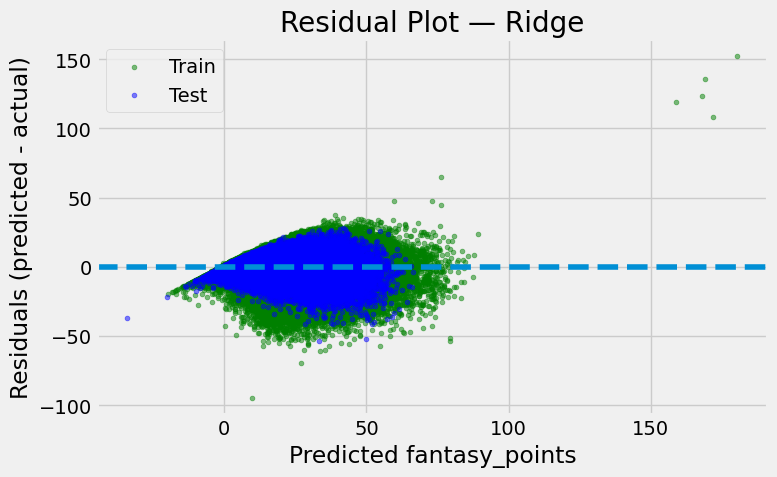

In [76]:
plot_residuals(best_ridge, X_train_E, y_train_E, X_test_E, y_test_E, "Ridge")

# XGBoost

In [80]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0
)

xgb.fit(X_train_E, y_train_E)

y_pred_xgb = xgb.predict(X_test_E)

In [81]:
rmse_ridge_xgb = root_mean_squared_error(y_test_E, y_pred_xgb)
r2_ridge_xgb = r2_score(y_test_E, y_pred_xgb)

print("RMSE: %.4f" %rmse_ridge_xgb)
print("R^2 score: %.4f" %r2_ridge_xgb)

RMSE: 7.1682
R^2 score: 0.7631


/tmp/ipykernel_8081/3104138102.py:38: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/malcolm-cs50/projects/NBA-Fantasy-Points/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


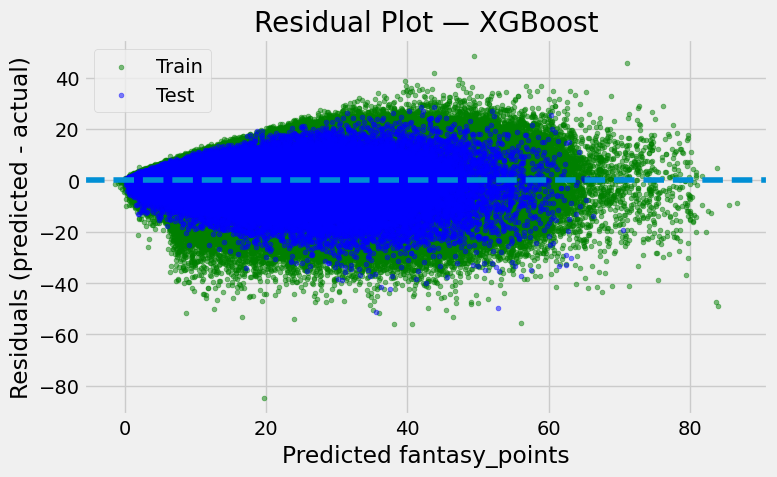

In [82]:
plot_residuals(xgb, X_train_E , y_train_E, X_test_E, y_test_E, "XGBoost")